# Sales Prediction using Python

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


### Load the Dataset

In [3]:
# Dataset: "Advertising and Sales" on Kaggle
df = pd.read_csv('/kaggle/input/datasets/bumba5341/advertisingcsv/Advertising.csv')

print("=== Dataset Preview ===")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== Dataset Preview ===
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
5           6    8.7   48.9       75.0    7.2
6           7   57.5   32.8       23.5   11.8
7           8  120.2   19.6       11.6   13.2
8           9    8.6    2.1        1.0    4.8
9          10  199.8    2.6       21.2   10.6

Shape: (200, 5)

Columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Data types:
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


### Data Cleaning & Exploration

In [4]:
# Basic statistics
print("=== Statistical Summary ===")
print(df.describe())

# Clean column names
df.columns = df.columns.str.strip().str.lower()
print(f"\nCleaned columns: {df.columns.tolist()}")

# Drop missing values if any
df.dropna(inplace=True)
print(f"\nFinal dataset shape: {df.shape}")

# Correlation with Sales
print("\n=== Correlation with Sales ===")
print(df.corr()['sales'].sort_values(ascending=False))

=== Statistical Summary ===
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000

Cleaned columns: ['unnamed: 0', 'tv', 'radio', 'newspaper', 'sales']

Final dataset shape: (200, 5)

=== Correlation with Sales ===
sales         1.000000
tv            0.782224
radio         0.576223
newspaper     0.228299
unnamed: 0   -0.051616
Name: sales, dtype: float64


### Visualization 1: Distribution & Correlation

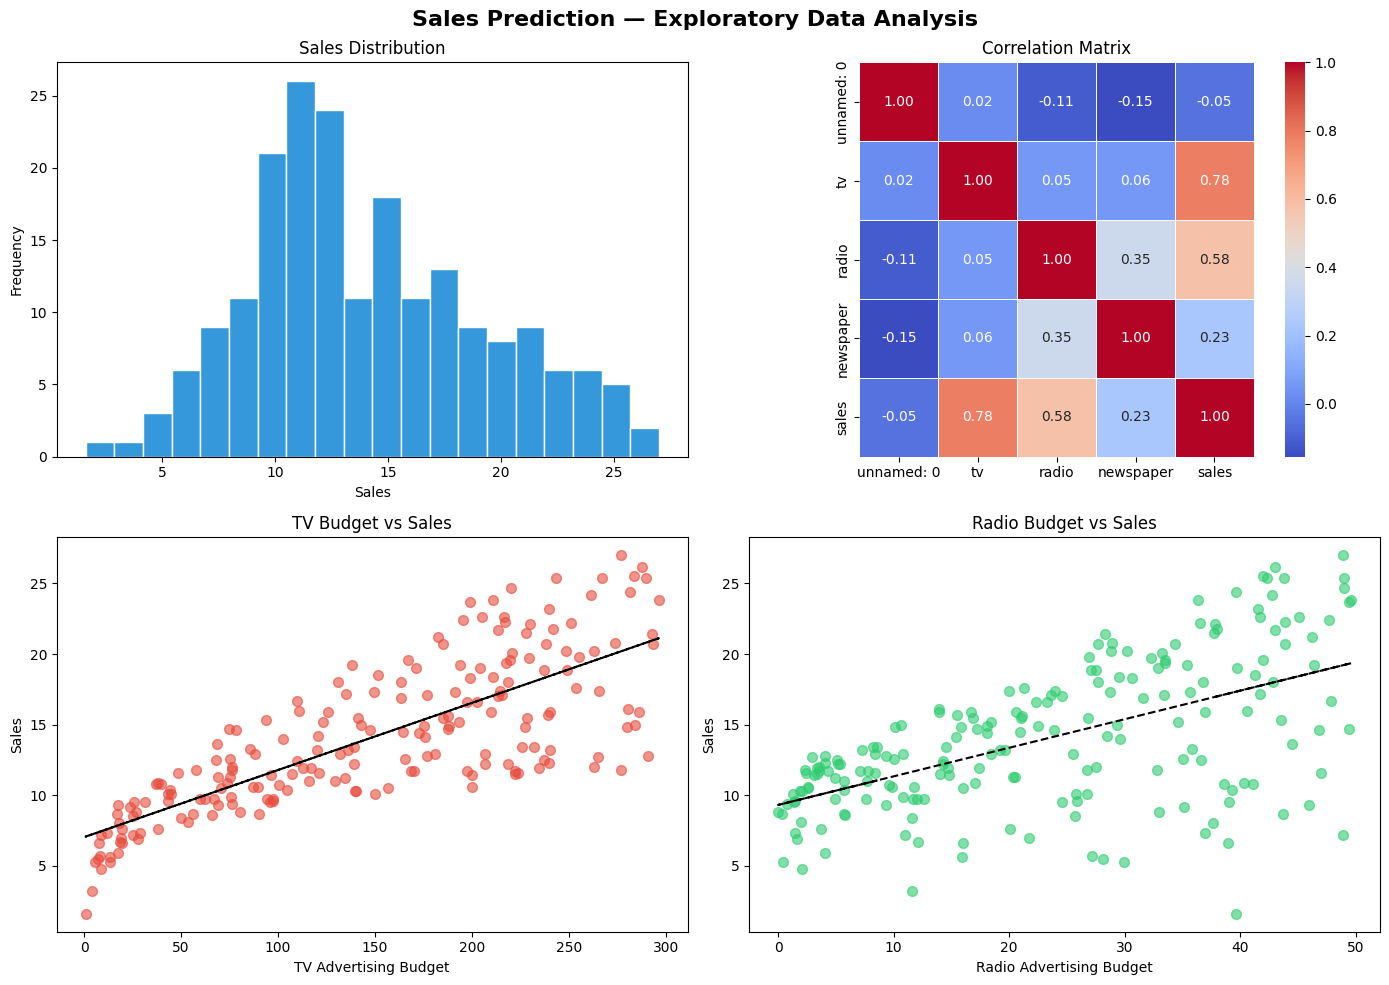

Chart saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Prediction — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Sales distribution
axes[0, 0].hist(df['sales'], bins=20, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Sales Distribution')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# 2. Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0, 1], square=True, linewidths=0.5)
axes[0, 1].set_title('Correlation Matrix')

# 3. TV spend vs Sales
axes[1, 0].scatter(df['tv'], df['sales'], color='#e74c3c', alpha=0.6, s=50)
axes[1, 0].set_xlabel('TV Advertising Budget')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].set_title('TV Budget vs Sales')

# Add regression line
m, b = np.polyfit(df['tv'], df['sales'], 1)
axes[1, 0].plot(df['tv'], m * df['tv'] + b, color='black', linewidth=1.5, linestyle='--')

# 4. Radio spend vs Sales
axes[1, 1].scatter(df['radio'], df['sales'], color='#2ecc71', alpha=0.6, s=50)
axes[1, 1].set_xlabel('Radio Advertising Budget')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].set_title('Radio Budget vs Sales')

m2, b2 = np.polyfit(df['radio'], df['sales'], 1)
axes[1, 1].plot(df['radio'], m2 * df['radio'] + b2, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('eda_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Visualization 2: Advertising Budget Breakdown

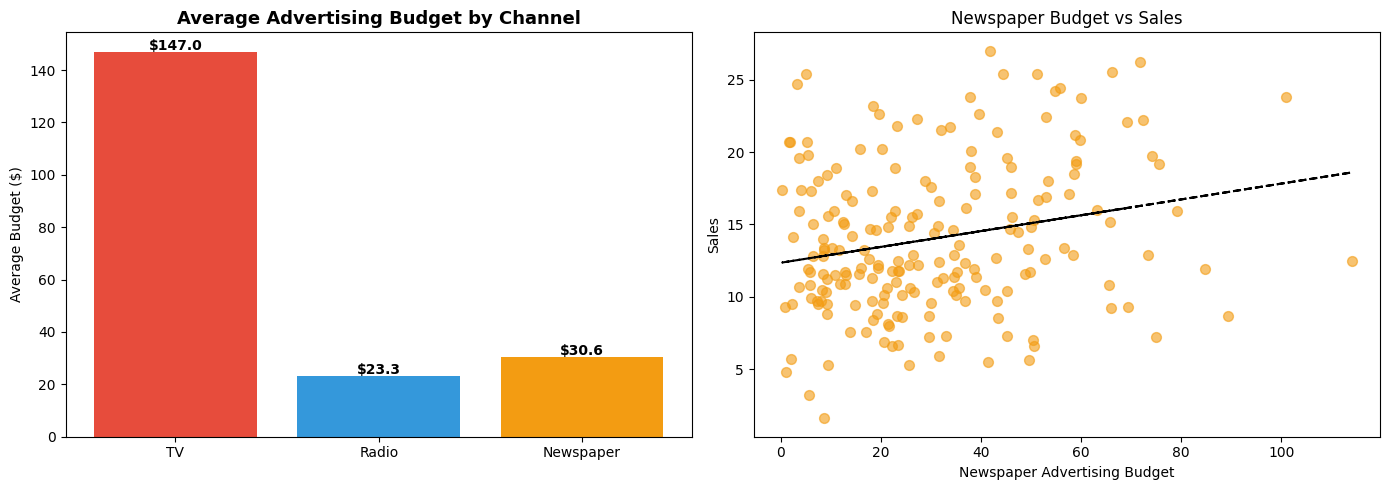

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average budget per channel
channels = ['tv', 'radio', 'newspaper']
averages = [df[c].mean() for c in channels]
colors   = ['#e74c3c', '#3498db', '#f39c12']

bars = axes[0].bar(['TV', 'Radio', 'Newspaper'], averages, color=colors)
axes[0].set_title('Average Advertising Budget by Channel', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Budget ($)')
for bar, val in zip(bars, averages):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', fontweight='bold')

# Right: Newspaper spend vs Sales
axes[1].scatter(df['newspaper'], df['sales'], color='#f39c12', alpha=0.6, s=50)
axes[1].set_xlabel('Newspaper Advertising Budget')
axes[1].set_ylabel('Sales')
axes[1].set_title('Newspaper Budget vs Sales')

m3, b3 = np.polyfit(df['newspaper'], df['sales'], 1)
axes[1].plot(df['newspaper'], m3 * df['newspaper'] + b3,
             color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('budget_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

###  Prepare the Data

In [7]:
# Features and target
X = df[['tv', 'radio', 'newspaper']]
y = df['sales']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nFeatures used: {X.columns.tolist()}")

Training samples : 160
Testing samples  : 40

Features used: ['tv', 'radio', 'newspaper']


### Train 3 Models

In [8]:
# Define models
models = {
    'Linear Regression'    : LinearRegression(),
    'Random Forest'        : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("=== Model Training Results ===\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model'      : model,
        'predictions': y_pred,
        'MAE'        : mae,
        'RMSE'       : rmse,
        'R2'         : r2
    }

    print(f"{name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R²   : {r2:.4f}")
    print()

=== Model Training Results ===

Linear Regression
  MAE  : 1.461
  RMSE : 1.782
  R²   : 0.8994

Random Forest
  MAE  : 0.621
  RMSE : 0.769
  R²   : 0.9813

Gradient Boosting
  MAE  : 0.618
  RMSE : 0.729
  R²   : 0.9831



### Model Comparison & Evaluation

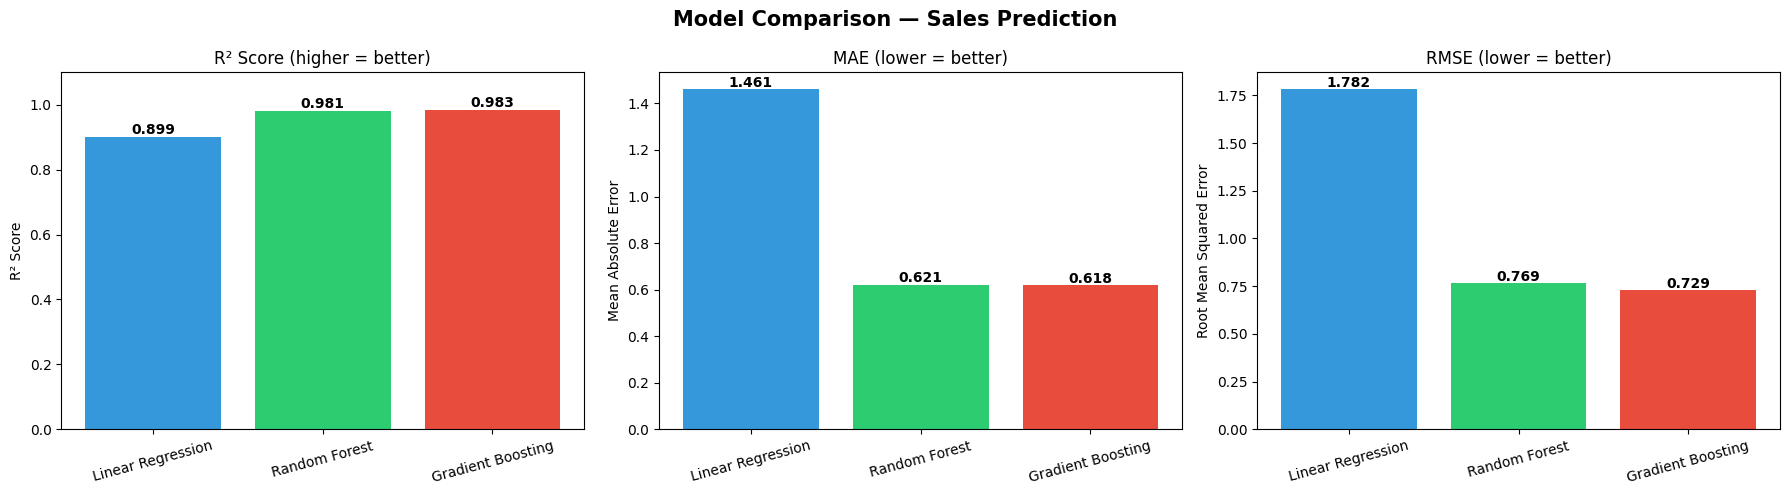

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — Sales Prediction', fontsize=15, fontweight='bold')

names     = list(results.keys())
r2_scores = [results[n]['R2']   for n in names]
mae_vals  = [results[n]['MAE']  for n in names]
rmse_vals = [results[n]['RMSE'] for n in names]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']

# R² Score
bars = axes[0].bar(names, r2_scores, color=bar_colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('R² Score')
for bar, v in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# MAE
bars2 = axes[1].bar(names, mae_vals, color=bar_colors)
axes[1].set_title('MAE (lower = better)')
axes[1].set_ylabel('Mean Absolute Error')
for bar, v in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# RMSE
bars3 = axes[2].bar(names, rmse_vals, color=bar_colors)
axes[2].set_title('RMSE (lower = better)')
axes[2].set_ylabel('Root Mean Squared Error')
for bar, v in zip(bars3, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Actual vs Predicted (Best Model)

Best model: Gradient Boosting (R² = 0.9831)


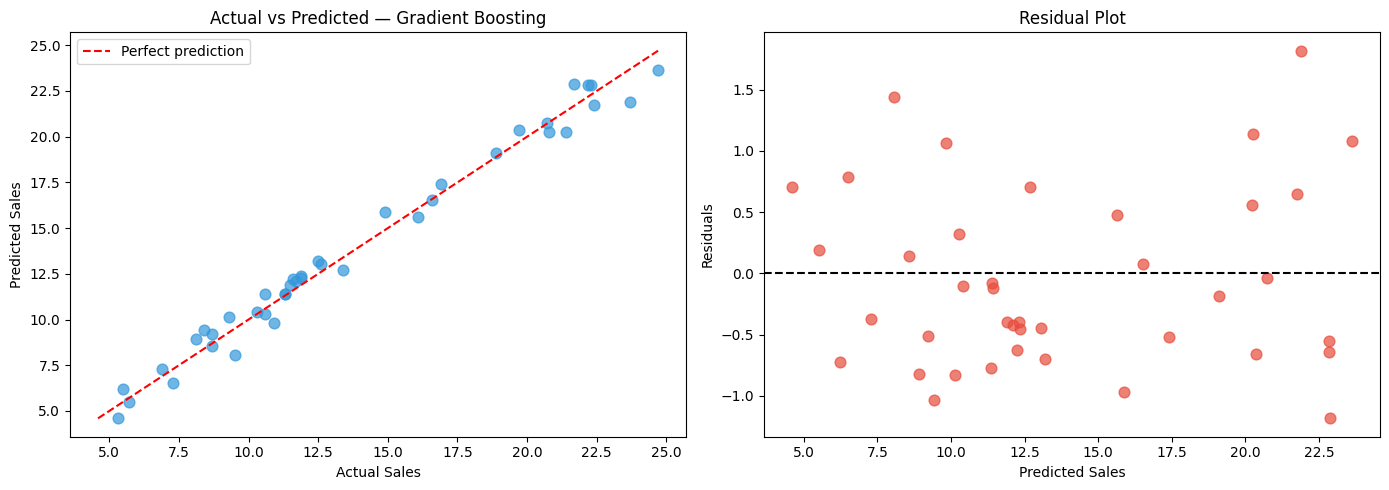

In [10]:
# Select best model by R²
best_name = max(results, key=lambda k: results[k]['R2'])
best      = results[best_name]
y_pred    = best['predictions']

print(f"Best model: {best_name} (R² = {best['R2']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, color='#3498db', alpha=0.7, s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

# Right: Residuals
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, color='#e74c3c', alpha=0.7, s=60)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance

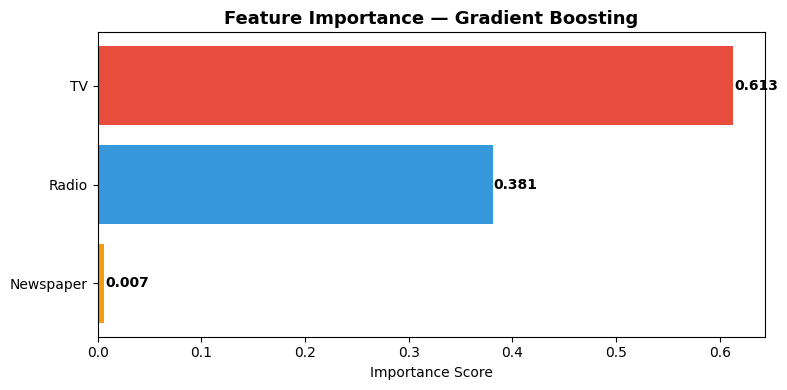

In [11]:
# Feature importance (for tree-based models)
best_model = best['model']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({
        'Feature'   : ['TV', 'Radio', 'Newspaper'],
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(8, 4))
    colors = ['#f39c12', '#3498db', '#e74c3c']
    plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    for i, v in enumerate(feat_df['Importance']):
        plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(best_model, 'coef_'):
    # Linear Regression coefficients
    coef_df = pd.DataFrame({
        'Feature'    : ['TV', 'Radio', 'Newspaper'],
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', ascending=True)

    plt.figure(figsize=(8, 4))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'],
             color=['#f39c12', '#3498db', '#e74c3c'])
    plt.xlabel('Coefficient Value')
    plt.title('Feature Coefficients — Linear Regression', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

### Predict New Sales

In [12]:
# Simulate new advertising budgets
new_campaigns = pd.DataFrame({
    'tv'       : [200, 50,  300],
    'radio'    : [30,  10,  60],
    'newspaper': [20,  5,   40]
})

new_scaled = scaler.transform(new_campaigns)
predictions = best['model'].predict(new_scaled)

print("=== Sales Prediction for New Campaigns ===\n")
print(f"{'TV':>8} {'Radio':>8} {'Newspaper':>12} {'Predicted Sales':>17}")
print("-" * 50)
for i, row in new_campaigns.iterrows():
    print(f"{row['tv']:>8.0f} {row['radio']:>8.0f} {row['newspaper']:>12.0f} {predictions[i]:>17.2f}")

=== Sales Prediction for New Campaigns ===

      TV    Radio    Newspaper   Predicted Sales
--------------------------------------------------
     200       30           20             18.20
      50       10            5              9.56
     300       60           40             26.88


### Key Insights Summary

In [13]:
print("=" * 55)
print("       SALES PREDICTION — KEY INSIGHTS")
print("=" * 55)

print(f"\n - Best model          : {best_name}")
print(f" - R² Score            : {best['R2']:.4f}")
print(f" - MAE                 : {best['MAE']:.3f}")
print(f" - RMSE                : {best['RMSE']:.3f}")

print(f"\n - Average Sales       : {df['sales'].mean():.2f}")
print(f" - Max Sales           : {df['sales'].max():.2f}")
print(f" - Min Sales           : {df['sales'].min():.2f}")

print(f"\n - Strongest predictor : TV (highest correlation with sales)")
print(f" - Weakest predictor   : Newspaper (lowest correlation)")

print("\n - Business Insight:")
print("   → Investing more in TV and Radio advertising")
print("     leads to significantly higher sales.")
print("   → Newspaper spend has minimal impact.")

print("\n" + "=" * 55)
print("Analysis complete! Check the saved charts above.")
print("=" * 55)

       SALES PREDICTION — KEY INSIGHTS

 - Best model          : Gradient Boosting
 - R² Score            : 0.9831
 - MAE                 : 0.618
 - RMSE                : 0.729

 - Average Sales       : 14.02
 - Max Sales           : 27.00
 - Min Sales           : 1.60

 - Strongest predictor : TV (highest correlation with sales)
 - Weakest predictor   : Newspaper (lowest correlation)

 - Business Insight:
   → Investing more in TV and Radio advertising
     leads to significantly higher sales.
   → Newspaper spend has minimal impact.

Analysis complete! Check the saved charts above.
